In [1]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')


### Poziom istotności
$$\alpha = 0.05$$

### Uzasadnienie wyboru testu
Dane mają rozkład normalny (założenie z zadania), próba mała ($n=15$), odchylenie populacji nieznane → **jednoprólkowy test t-Studenta** (dwustronny).

In [6]:
alpha = 0.05
mu0 = 35

baterie = np.array([35.34, 36.26, 30.54, 38.2, 37.59, 39.18,
                    33.16, 34.23, 27.9, 36.33, 32.39, 34.89,
                    35.7, 31.99, 34.03])

n = len(baterie)
x_bar = np.mean(baterie)
s = np.std(baterie, ddof=1)

t_stat, p_value = stats.ttest_1samp(baterie, mu0)

print(f"n       = {n}")
print(f"x̄       = {x_bar:.4f} h")
print(f"s       = {s:.4f} h")
print(f"t       = {t_stat:.4f}")
print(f"p-value = {p_value:.4f}")
print(f"α       = {alpha}")
print()


n       = 15
x̄       = 34.5153 h
s       = 2.9996 h
t       = -0.6258
p-value = 0.5415
α       = 0.05




DECYZJA: Brak podstaw do odrzucenia H₀.
Wniosek: Brak istotnych podstaw, by twierdzić, że przeciętny czas pracy różni się od 35 h (p=0.5415 ≥ α=0.05).

### Poziom istotności
$$\alpha = 0.05$$

### Uzasadnienie wyboru testu
Próba $n = 52$ — przy $n \leq 50$ standardowo stosuje się **Shapiro–Wilka**, przy $n > 50$ zaleca się **Kołmogorowa–Smirnova (Lillieforsa)** lub **chi-kwadrat** (dane grupowalne). Użyjemy obu: Shapiro–Wilka (scipy nie ogranicza go do 50) jako podstawowego oraz D'Agostino–Pearsona jako weryfikacji.

n = 52, x̄ = 64.615, s = 3.132

Shapiro–Wilk:        W = 0.9794,  p = 0.5005
D'Agostino–Pearson:  K² = 1.6386, p = 0.4407
Kołmogorow–Smirnow:  D = 0.0845,  p = 0.8217  (uwaga: p tu zawyżone – estymowane parametry)



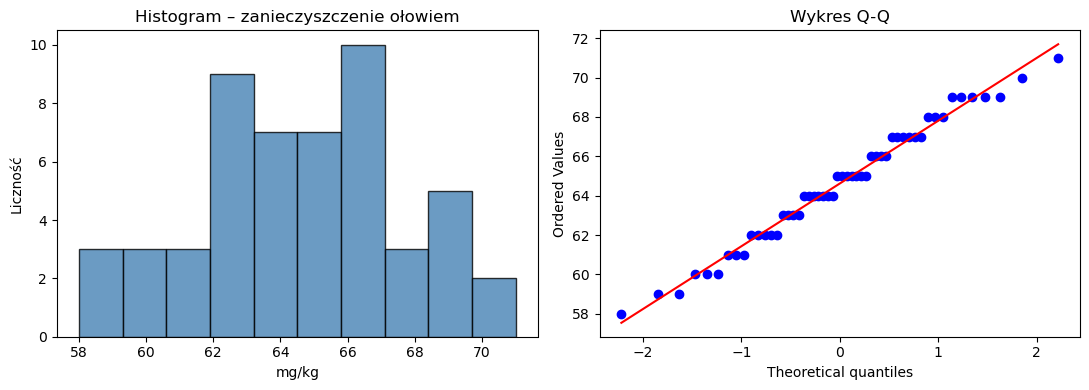

In [8]:
alpha = 0.05

lead = np.array([
    59, 60, 62, 58, 59, 61, 65, 67, 65, 65, 62, 65, 67,
    69, 64, 65, 66, 67, 64, 66, 68, 64, 63, 64, 67, 69,
    62, 64, 67, 68, 69, 61, 62, 69, 63, 65, 60, 60, 65,
    63, 70, 68, 67, 71, 61, 64, 63, 66, 62, 64, 66, 69
])

n = len(lead)
print(f"n = {n}, x̄ = {np.mean(lead):.3f}, s = {np.std(lead, ddof=1):.3f}")
print()

stat_sw, p_sw = stats.shapiro(lead)
print(f"Shapiro–Wilk:        W = {stat_sw:.4f},  p = {p_sw:.4f}")

stat_dp, p_dp = stats.normaltest(lead)
print(f"D'Agostino–Pearson:  K² = {stat_dp:.4f}, p = {p_dp:.4f}")

stat_ks, p_ks = stats.kstest(lead, 'norm', args=(np.mean(lead), np.std(lead, ddof=1)))
print(f"Kołmogorow–Smirnow:  D = {stat_ks:.4f},  p = {p_ks:.4f}  (uwaga: p tu zawyżone – estymowane parametry)")
print()


fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(lead, bins=10, edgecolor='black', color='steelblue', alpha=0.8)
axes[0].set_title('Histogram – zanieczyszczenie ołowiem')
axes[0].set_xlabel('mg/kg')
axes[0].set_ylabel('Liczność')
stats.probplot(lead, dist='norm', plot=axes[1])
axes[1].set_title('Wykres Q-Q')
plt.tight_layout()
plt.show()

 Brak podstaw do odrzucenia H₀.
Wniosek: Brak podstaw, by odrzucić normalność rozkładu zanieczyszczenia ołowiem.


### Poziom istotności
$$\alpha = 0.05$$

### Uzasadnienie wyboru testu
Pomiary z tych samych zakładów w dwóch punktach czasu → **próby zależne (sparowane)**. Nie jest zakładana normalność różnic explicite, ale $n=10$ — sprawdzimy normalność różnic. Jeśli różnice są normalne → **sparowany t-Studenta (jednostronny)**; jeśli nie → **test Wilcoxona znakowanych rang (jednostronny)**.

In [10]:
alpha = 0.05

rok1 = np.array([220, 185, 270, 285, 200, 295, 255, 190, 225, 230])
rok2 = np.array([190, 175, 215, 260, 215, 195, 260, 150, 155, 175])
diff = rok1 - rok2

print(f"Różnice (Rok I − Rok II): {diff}")
print(f"Średnia różnic: {np.mean(diff):.2f}")
print()

# Sprawdzenie normalności różnic
_, p_norm = stats.shapiro(diff)
print(f"Shapiro-Wilk dla różnic: p = {p_norm:.4f}")

if p_norm >= alpha:
    print("t-test")
    # jednostronny: alternative='greater' bo liczymy Rok I - Rok II
    t_stat, p_two = stats.ttest_rel(rok1, rok2)
    p_one = p_two / 2 if t_stat > 0 else 1 - p_two / 2
    print(f"t = {t_stat:.4f},  p (jednostronne) = {p_one:.4f}")
    p_test = p_one
else:
    print("wilcoxon")
    stat_w, p_test = stats.wilcoxon(diff, alternative='greater')
    print(f"W = {stat_w:.4f},  p (jednostronne) = {p_test:.4f}")



Różnice (Rok I − Rok II): [ 30  10  55  25 -15 100  -5  40  70  55]
Średnia różnic: 36.50

Shapiro-Wilk dla różnic: p = 0.9719
t-test
t = 3.2863,  p (jednostronne) = 0.0047



Odrzucamy H₀.
Wniosek: Na poziomie istotności 0.05 nastąpił ISTOTNY STATYSTYCZNIE SPADEK emisji pyłów.

---
## Zadanie 4 – Jednoprólkowy test t-Studenta (zużycie paliwa statków)

### Hipotezy
**Słownie:**  
- $H_0$: Przy prędkości 17 węzłów dzienne zużycie paliwa wynosi co najmniej 127.7 t (komisja nie ma racji).  
- $H_1$: Przy prędkości 17 węzłów dzienne zużycie paliwa jest mniejsze niż 127.7 t (komisja ma rację).

**Matematycznie:**  
$$H_0: \mu \geq 127.7 \quad \text{vs} \quad H_1: \mu < 127.7$$

### Poziom istotności
$$\alpha = 0.01$$

### Uzasadnienie wyboru testu
Dane mają rozkład normalny (założenie z zadania), próba mała ($n=5$), odchylenie populacji nieznane → **jednoprólkowy t-Studenta (jednostronny lewy)**.

In [ ]:
alpha = 0.01
mu0 = 127.7

paliwo = np.array([101.1, 105.7, 102.6, 113.4, 98.1])

n = len(paliwo)
x_bar = np.mean(paliwo)
s = np.std(paliwo, ddof=1)

t_stat, p_value = stats.ttest_1samp(paliwo, mu0, alternative='less')

print(f"n       = {n}")
print(f"x̄       = {x_bar:.4f} t")
print(f"s       = {s:.4f} t")
print(f"t       = {t_stat:.4f}")
print(f"p-value = {p_value:.6f}  (jednostronne, lewe)")
print(f"α       = {alpha}")

t_crit = stats.t.ppf(alpha, df=n-1)
print(f"t_kryt  = {t_crit:.4f}  (dla α={alpha}, df={n-1})")
print()


n       = 5
x̄       = 104.1800 t
s       = 5.8367 t
t       = -9.0106
p-value = 0.000420  (jednostronne, lewe)
α       = 0.01
t_kryt  = -3.7469  (dla α=0.01, df=4)

DECYZJA: Odrzucamy H₀.
Wniosek: Dane potwierdzają słuszność Komisji — obniżenie prędkości do 17 węzłów
         ISTOTNIE ZMNIEJSZA dzienne zużycie paliwa poniżej 127.7 t (p=0.000420 < α=0.01).


Odrzucamy H₀.
Dane potwierdzają słuszność Komisji — obniżenie prędkości do 17 węzłów
ISTOTNIE ZMNIEJSZA dzienne zużycie paliwa poniżej 127.7 t (p=0.000420 < α=0.01).